# Balancing classes with `LanguageModelOverSampler`

`LanguageModelOverSampler` is the oversampling view of the shared fine-tune (see
`00-intro.ipynb`) and implements the imbalanced-learn sampler API (`fit_resample`). For each
under-represented class $c$, it conditions generation on the label and synthesizes the features —
that is, it samples

$$ x^{\text{new}} \sim p\!\left(\text{features} \mid \text{class} = c\right) $$

and appends those rows until the classes are balanced.

## Contrast with SMOTE

SMOTE builds a synthetic point by linear interpolation between a minority sample $x_i$ and one of
its neighbours $x_j$:

$$ x^{\text{new}} = x_i + \lambda\,(x_j - x_i), \qquad \lambda \sim \mathcal{U}(0, 1). $$

That requires a numeric vector space and a distance, so categorical columns must be encoded first,
and every synthetic point lies on a segment between two real ones. The LM oversampler instead
samples from the learned conditional, so it works **directly on mixed/categorical tables** and can
place mass anywhere the conditional supports — not only on the convex hull of the existing minority
points.

To check that it recovers the right distribution, we take balanced Iris, throw away most of one
class to make it a minority, oversample it back, then compare the **synthetic** rows against the
**real** Iris rows of that class — rows the model never fully saw.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

from sklm import JupyterCallback, LanguageModelOverSampler, TrainingConfig

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42
MINORITY = 2  # the Iris class we under-sample, then regenerate
KEEP = 20     # real rows of the minority class left for training

## Creating the imbalance

We drop all but `KEEP` rows of class `MINORITY`, leaving the other two classes intact.

In [2]:
iris = load_iris(as_frame=True)
X_full = iris.data.set_axis(
    ["sepal_length", "sepal_width", "petal_length", "petal_width"], axis=1
)
y_full = iris.target.to_numpy()

rng = np.random.RandomState(SEED)
minority_idx = np.where(y_full == MINORITY)[0]
drop = rng.choice(minority_idx, size=len(minority_idx) - KEEP, replace=False)
keep_mask = np.ones(len(y_full), dtype=bool)
keep_mask[drop] = False
X = X_full[keep_mask].reset_index(drop=True)
y = y_full[keep_mask]
pd.Series(y).value_counts().sort_index()

0    50
1    50
2    20
Name: count, dtype: int64

## Resampling

`fit_resample` fine-tunes once, then generates minority rows until the classes are balanced. The
returned `X_res` is the original data with the synthetic rows appended.

In [3]:
X_res, y_res = LanguageModelOverSampler(
    model="gabfssilva/distilgpt2",
    backend="mlx",
    training=TrainingConfig(
        epochs=6, batch_size=4, augmentation_factor=12
    ),
    random_state=SEED,
).fit_resample(X, y)
print(f"rows: {len(X)} -> {len(X_res)} ({len(X_res) - len(X)} synthesized)")

HTML(value='')

rows: 120 -> 150 (30 synthesized)


## Class distribution: before vs. after

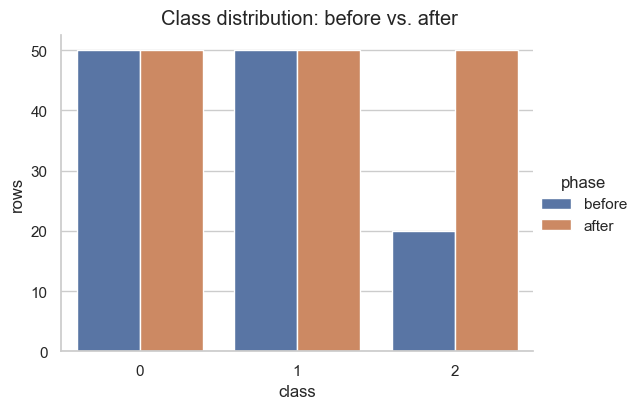

In [4]:
counts = (
    pd.DataFrame(
        {
            "before": pd.Series(y).value_counts().sort_index(),
            "after": pd.Series(y_res).value_counts().sort_index(),
        }
    )
    .reset_index(names="class")
    .melt(id_vars="class", var_name="phase", value_name="n")
)

g = sns.catplot(counts, kind="bar", x="class", y="n", hue="phase", height=4, aspect=1.4)
g.set_axis_labels("class", "rows")
g.figure.suptitle("Class distribution: before vs. after", y=1.02)
plt.show()

## Real vs. synthetic

First the per-feature moments: if the conditional was learned, the synthetic mean and standard
deviation should be close to the real minority class's.

In [5]:
synth = X_res.iloc[len(X):].reset_index(drop=True)
real = X_full[y_full == MINORITY]
comparison = pd.DataFrame(
    {
        "real_mean": real.mean(),
        "synth_mean": synth.mean(),
        "real_std": real.std(),
        "synth_std": synth.std(),
    }
).round(2)
comparison

,real_mean,synth_mean,real_std,synth_std
sepal_length,6.59,6.57,0.64,0.68
sepal_width,2.97,3.01,0.32,0.23
petal_length,5.55,5.40,0.55,0.40
petal_width,2.03,2.06,0.27,0.31


And the joint structure: the synthetic rows (orange) should overlap the real Iris rows of the
minority class (blue), which the model only ever saw `KEEP` examples of.

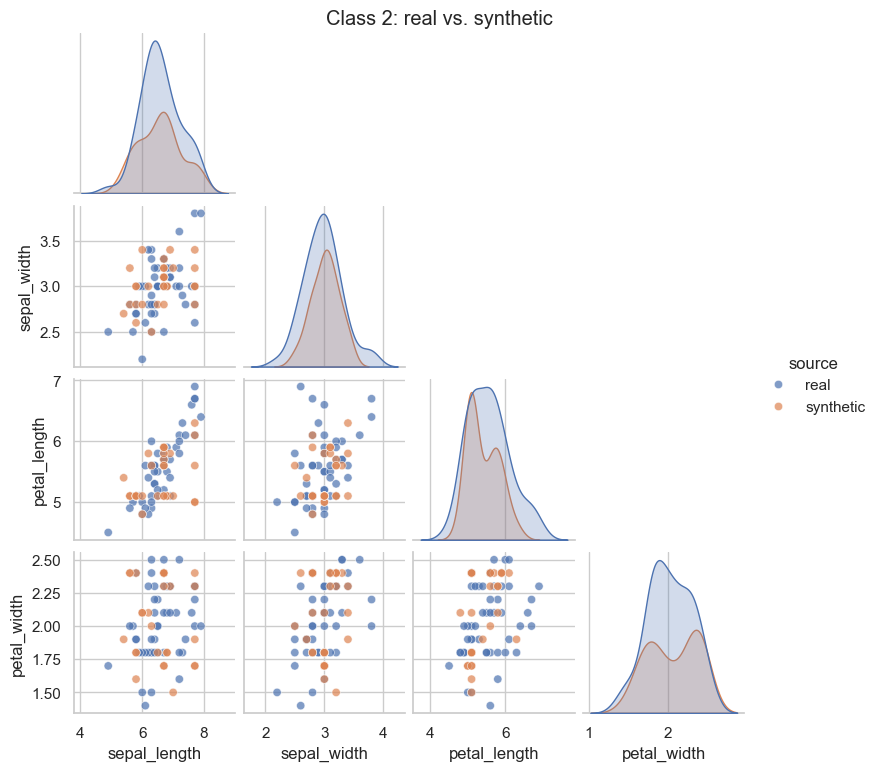

In [6]:
compare = pd.concat(
    [real.assign(source="real"), synth.assign(source="synthetic")], ignore_index=True
)
g = sns.pairplot(compare, hue="source", corner=True, height=1.9, plot_kws={"alpha": 0.7})
g.figure.suptitle(f"Class {MINORITY}: real vs. synthetic", y=1.01)
plt.show()